In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#Load Dataset
df = pd.read_csv("diabetes new dataset.csv")
df

C:\Users\aishwarya singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Mid,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,120.686254,109.388316,38.141407,138.210739,34.516049,0.258832,37.057632,0,Obese,Adult,Prediabetes
5996,2,118.503965,88.419612,34.813478,120.022208,27.536625,0.893585,48.831777,1,Overweight,Mid,Prediabetes
5997,2,108.388973,70.893077,45.317985,119.342180,35.907998,0.153524,20.391154,1,Obese,Young,Prediabetes
5998,2,111.119231,87.618313,37.901339,151.125654,30.020068,2.287700,40.615405,1,Obese,Mid,Prediabetes


In [2]:
#Show First 5 Rows
print(df.head())
#Dataset Information
print(df.info())
#Check Missing Values
print(df.isnull().sum())

   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            1  123.854532      70.552013      47.564623  140.225349   
1            1  117.297774      71.079050      41.263556  111.154260   
2            2  110.176908     100.378619      29.175547  117.197124   
3            2  116.422941      95.603386      32.177355  143.376177   
4            4   97.760847      77.837421      33.367973  121.180076   

         BMI  DiabetesPedigreeFunction        Age  Outcome BMI_Category  \
0  44.067900                  0.205703  40.960570        0        Obese   
1  29.703077                  1.136390  33.340828        0   Overweight   
2  28.162753                  1.915921  42.772262        0   Overweight   
3  31.713198                  2.046737  53.276358        1        Obese   
4  29.708066                  0.585468  32.190160        1   Overweight   

  Age_Group Glucose_Level  
0       Mid   Prediabetes  
1     Adult   Prediabetes  
2       Mid   Prediabetes  
3   

In [3]:
#Convert categorical columns into numerical
le = LabelEncoder()
df['BMI_Category'] = le.fit_transform(df['BMI_Category'])
df['Age_Group'] = le.fit_transform(df['Age_Group'])
df['Glucose_Level'] = le.fit_transform(df['Glucose_Level'])
# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
imputer=SimpleImputer(strategy='mean')
X=pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
xgb_model=XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
# Create model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               6000 non-null   int64  
 1   Glucose                   5400 non-null   float64
 2   BloodPressure             5400 non-null   float64
 3   SkinThickness             5400 non-null   float64
 4   Insulin                   5400 non-null   float64
 5   BMI                       5400 non-null   float64
 6   DiabetesPedigreeFunction  6000 non-null   float64
 7   Age                       6000 non-null   float64
 8   Outcome                   6000 non-null   int64  
 9   BMI_Category              6000 non-null   int64  
 10  Age_Group                 6000 non-null   int64  
 11  Glucose_Level             6000 non-null   int64  
dtypes: float64(7), int64(5)
memory usage: 562.6 KB
None


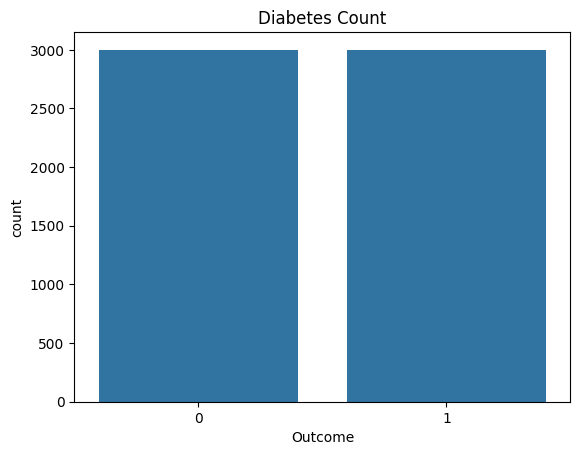

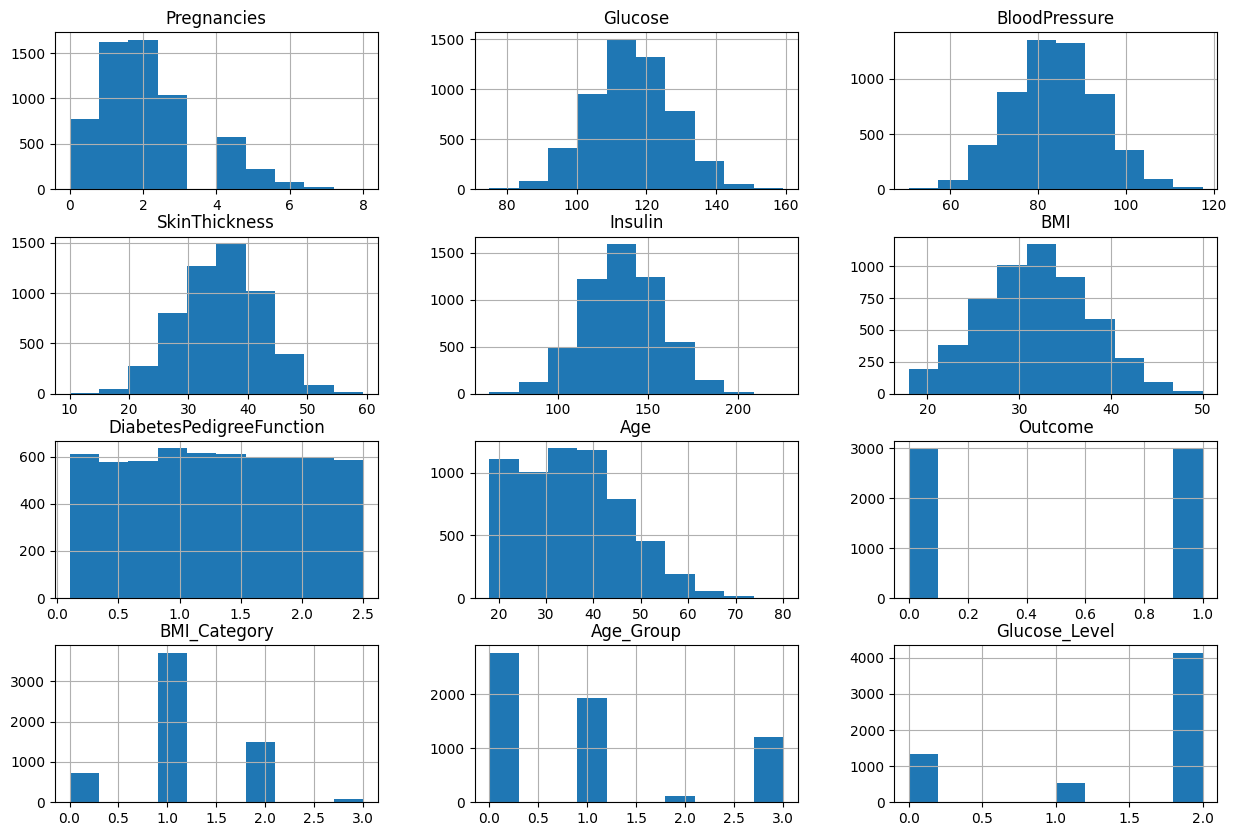

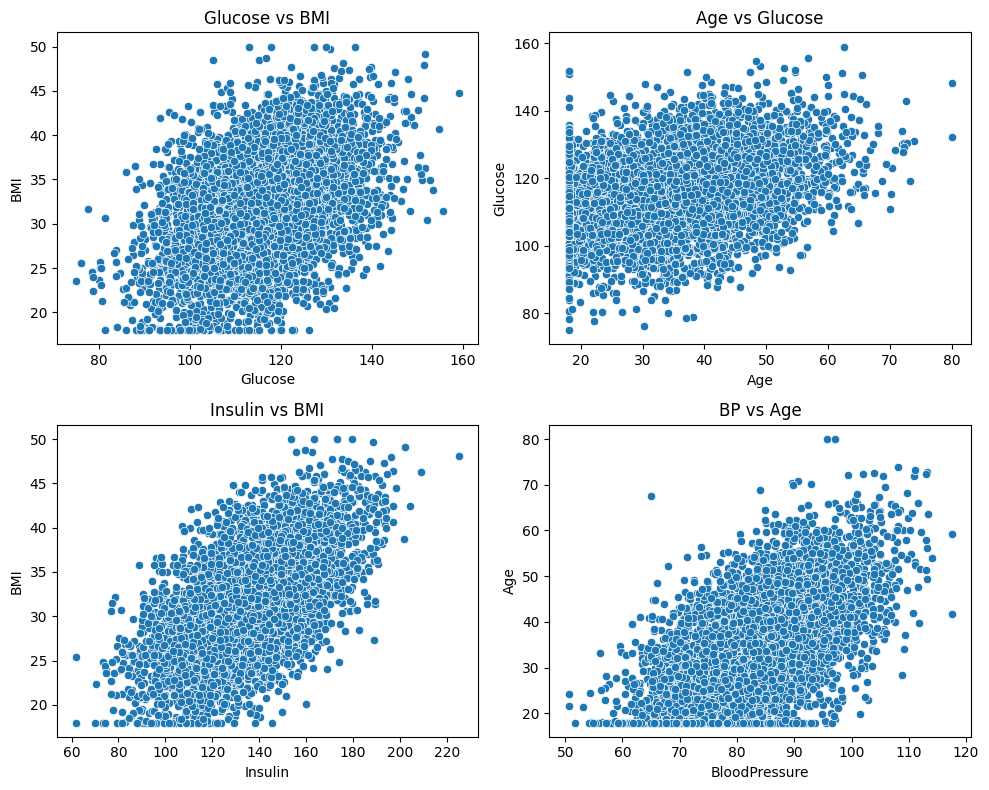

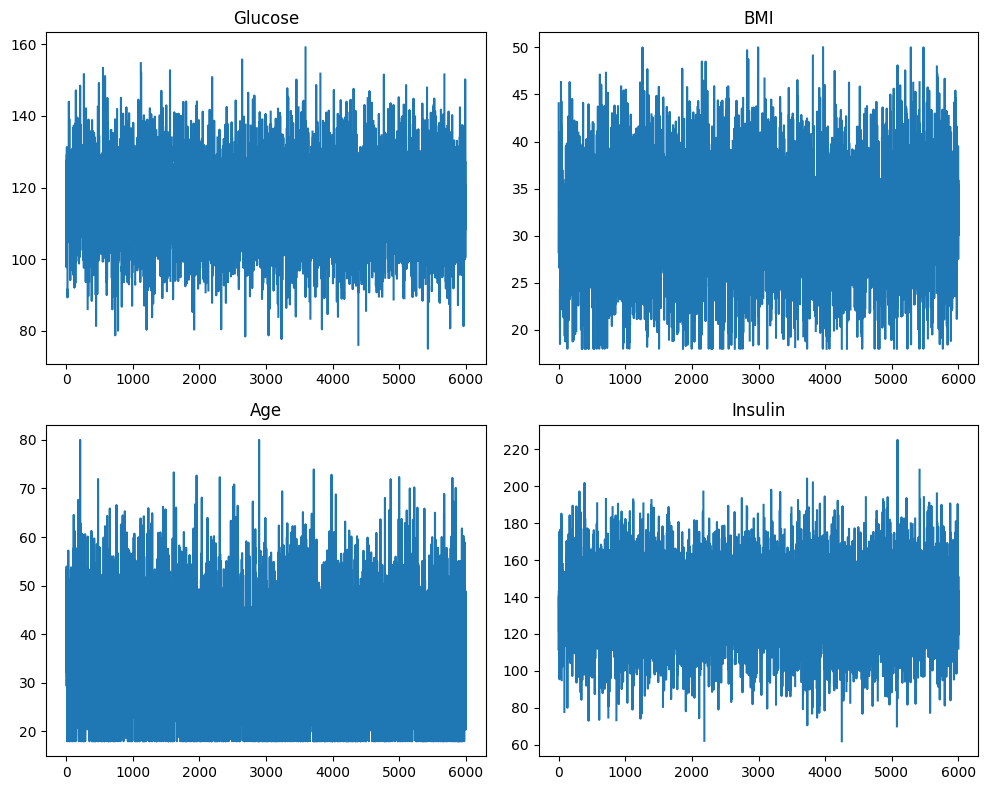

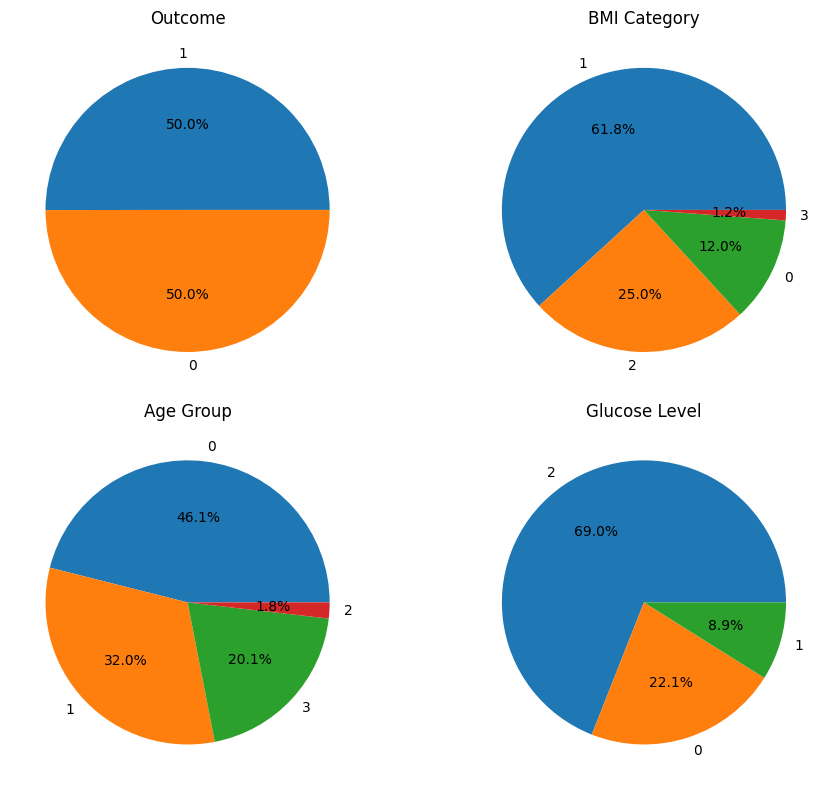

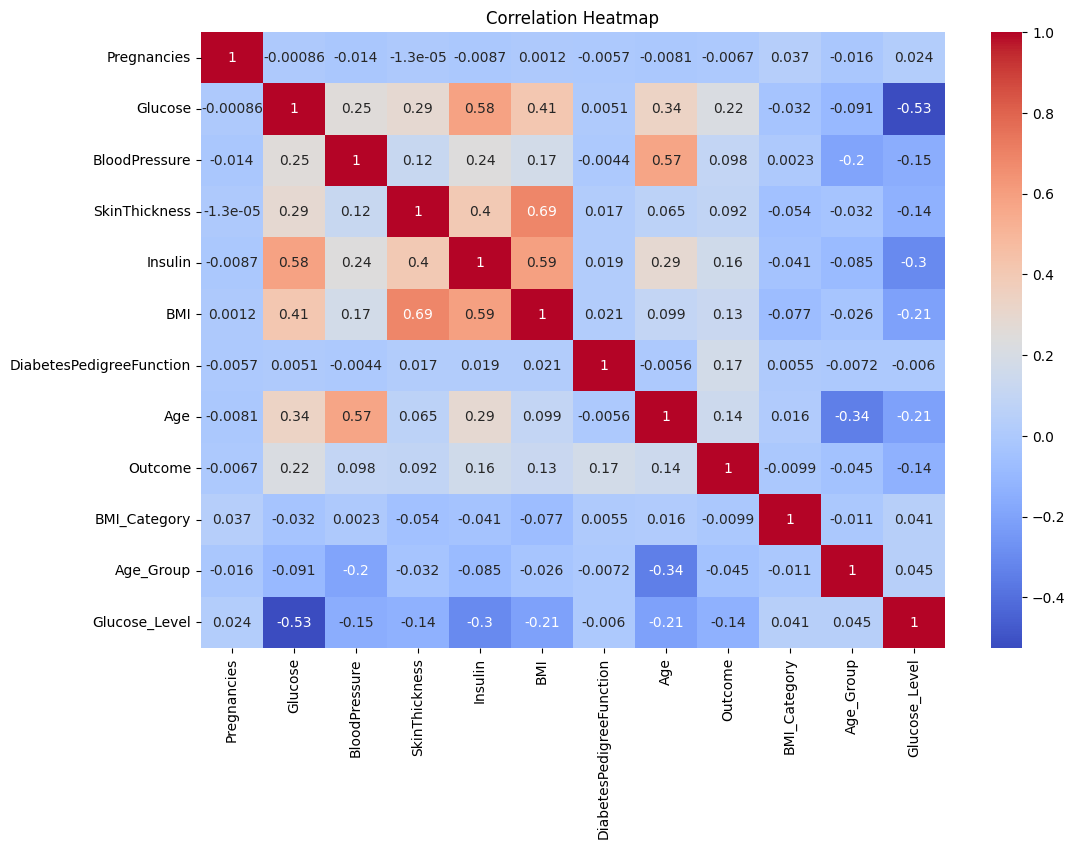

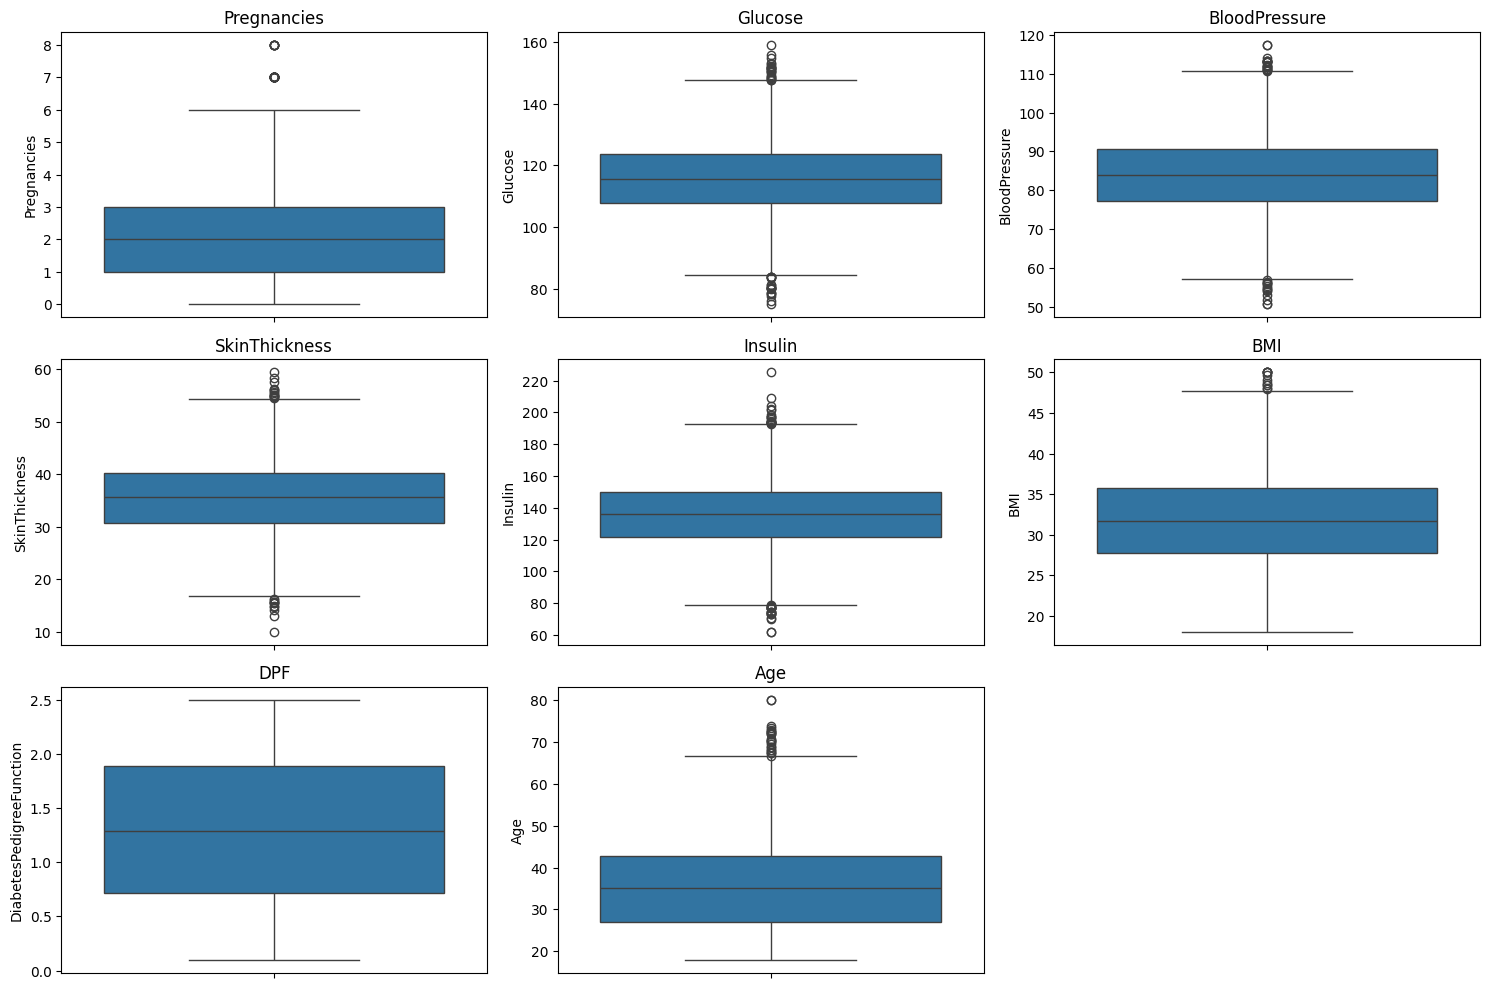

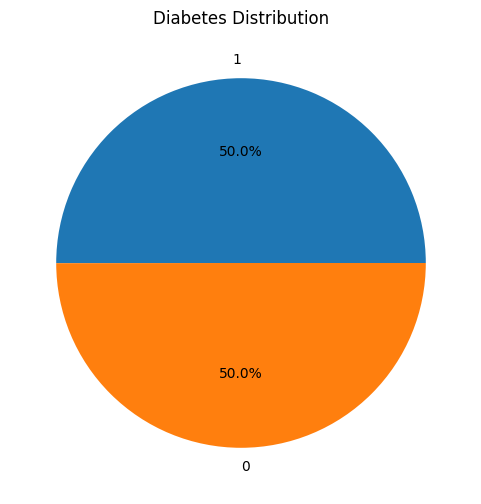

In [5]:
##Exploratory Data Analysi(EDA)
#Countplot
sns.countplot(x='Outcome',data=df)
plt.title("Diabetes Count")
plt.show()
#Histogram
df.hist(figsize=(15,10))
plt.show()
#Scatter Plot
fig, ax = plt.subplots(2, 2, figsize=(10,8))
sns.scatterplot(x='Glucose', y='BMI', data=df, ax=ax[0,0])
ax[0,0].set_title('Glucose vs BMI')
sns.scatterplot(x='Age', y='Glucose', data=df, ax=ax[0,1])
ax[0,1].set_title('Age vs Glucose')
sns.scatterplot(x='Insulin', y='BMI', data=df, ax=ax[1,0])
ax[1,0].set_title('Insulin vs BMI')
sns.scatterplot(x='BloodPressure', y='Age', data=df, ax=ax[1,1])
ax[1,1].set_title('BP vs Age')
plt.tight_layout()
plt.show()
#Line Plot
fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax[0,0].plot(df['Glucose'])
ax[0,0].set_title('Glucose')
ax[0,1].plot(df['BMI'])
ax[0,1].set_title('BMI')
ax[1,0].plot(df['Age'])
ax[1,0].set_title('Age')
ax[1,1].plot(df['Insulin'])
ax[1,1].set_title('Insulin')
plt.tight_layout()
plt.show()
#Pie Chart(Multiple)
fig, ax = plt.subplots(2, 2, figsize=(10,8))
# 1. Outcome
df['Outcome'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[0,0], title='Outcome')
ax[0,0].set_ylabel('')
# 2. BMI Category
df['BMI_Category'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[0,1], title='BMI Category')
ax[0,1].set_ylabel('')
# 3. Age Group
df['Age_Group'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[1,0], title='Age Group')
ax[1,0].set_ylabel('')
# 4. Glucose Level
df['Glucose_Level'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[1,1], title='Glucose Level')
ax[1,1].set_ylabel('')
plt.tight_layout()
plt.show()
#Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#BoxPlot
fig, ax = plt.subplots(3, 3, figsize=(15,10))
# Row 1
sns.boxplot(y=df['Pregnancies'], ax=ax[0,0])
ax[0,0].set_title('Pregnancies')
sns.boxplot(y=df['Glucose'], ax=ax[0,1])
ax[0,1].set_title('Glucose')
sns.boxplot(y=df['BloodPressure'], ax=ax[0,2])
ax[0,2].set_title('BloodPressure')
# Row 2
sns.boxplot(y=df['SkinThickness'], ax=ax[1,0])
ax[1,0].set_title('SkinThickness')
sns.boxplot(y=df['Insulin'], ax=ax[1,1])
ax[1,1].set_title('Insulin')
sns.boxplot(y=df['BMI'], ax=ax[1,2])
ax[1,2].set_title('BMI')
# Row 3
sns.boxplot(y=df['DiabetesPedigreeFunction'], ax=ax[2,0])
ax[2,0].set_title('DPF')
sns.boxplot(y=df['Age'], ax=ax[2,1])
ax[2,1].set_title('Age')
# Empty last box
ax[2,2].axis('off')
plt.tight_layout()
plt.show()
#Pie Chart
df['Outcome'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Diabetes Distribution")
plt.ylabel("")
plt.show()

[0 1 0 ... 1 0 1]


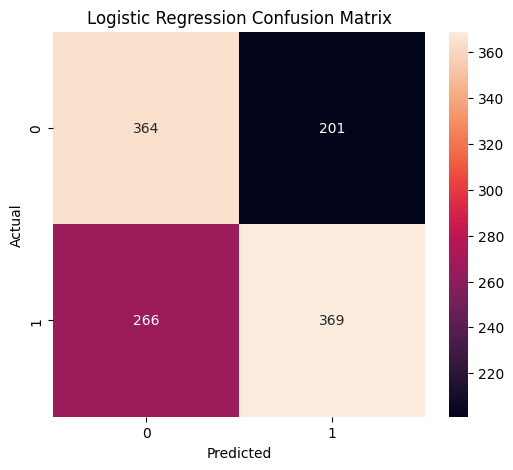

In [9]:
##Train Model
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(y_pred1)

#Confusion Matrix
cm1=confusion_matrix(y_test,y_pred1)
plt.figure(figsize=(6,5))
sns.heatmap(cm1,annot=True,fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 0.5708333333333333


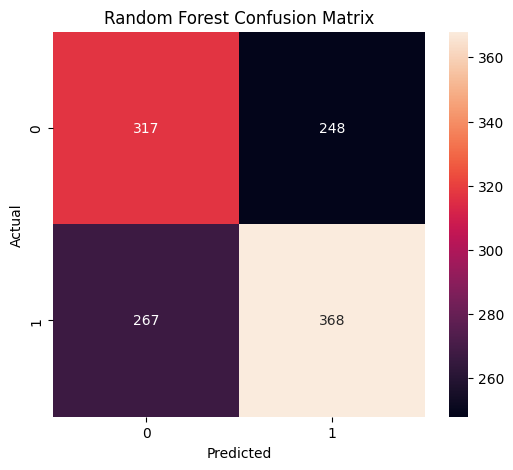

In [10]:
#Random Forest
model2=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred2))

#Confusion Matrix
cm2=confusion_matrix(y_test,y_pred2)
plt.figure(figsize=(6,5))
sns.heatmap(cm2,annot=True,fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

[1 0 0 ... 1 0 0]


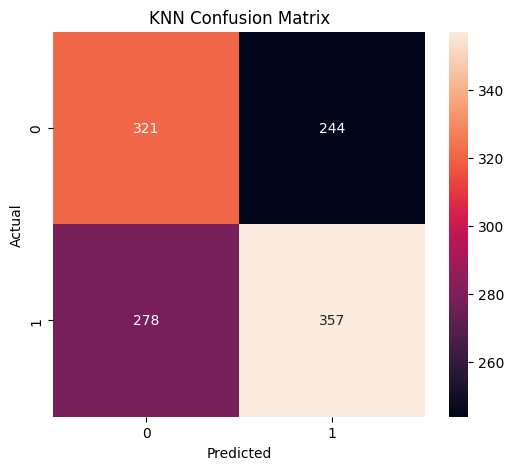

              precision    recall  f1-score   support

           0       0.54      0.57      0.55       565
           1       0.59      0.56      0.58       635

    accuracy                           0.56      1200
   macro avg       0.56      0.57      0.56      1200
weighted avg       0.57      0.56      0.57      1200



In [11]:
# KNN Model
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
# Train
knn_model.fit(X_train, y_train)
# Prediction
y_pred_knn = knn_model.predict(X_test)
print(y_pred_knn)

#Confusion Matrix
cm_knn=confusion_matrix(y_test,y_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn,annot=True,fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Classification Report
print(classification_report(y_test,y_pred_knn))

[0 1 0 ... 1 0 0]


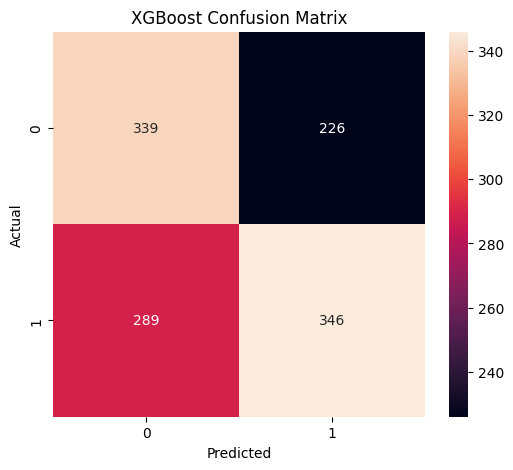

              precision    recall  f1-score   support

           0       0.54      0.60      0.57       565
           1       0.60      0.54      0.57       635

    accuracy                           0.57      1200
   macro avg       0.57      0.57      0.57      1200
weighted avg       0.57      0.57      0.57      1200



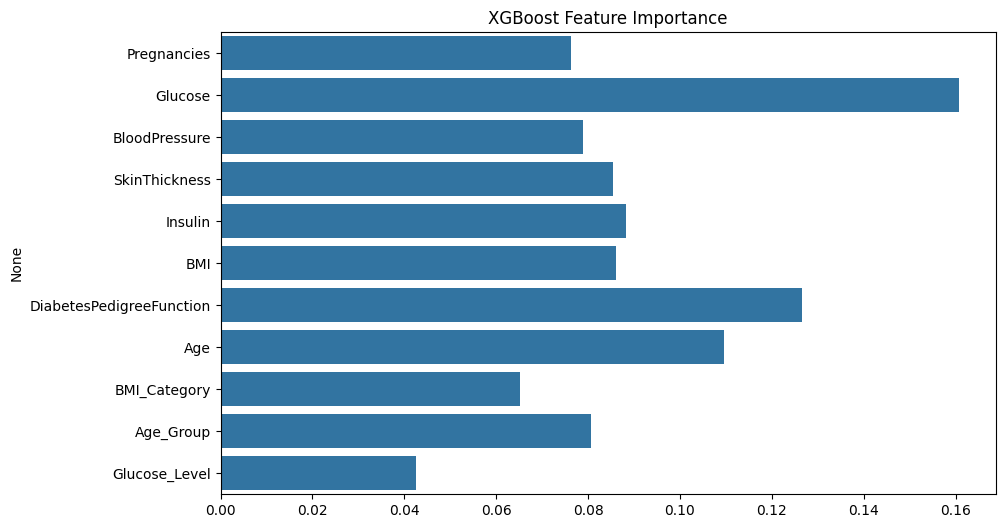

In [12]:
# XGBoost Model
from xgboost import XGBClassifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
# Train XGBoost
xgb_model.fit(X_train, y_train)
# Prediction
y_pred_xgb = xgb_model.predict(X_test)
print(y_pred_xgb)

#Confusion Matrix
cm3=confusion_matrix(y_test,y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm3,annot=True,fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Classification Report
print(classification_report(y_test,y_pred_xgb))

# Feature Importance
importance = xgb_model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=features)
plt.title("XGBoost Feature Importance")
plt.show()

In [13]:
#Accuracy Comparison
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred1))
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred2))
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))
print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.6108333333333333
Random Forest Accuracy: 0.5708333333333333
KNN Accuracy: 0.565
XGBoost Accuracy: 0.5708333333333333


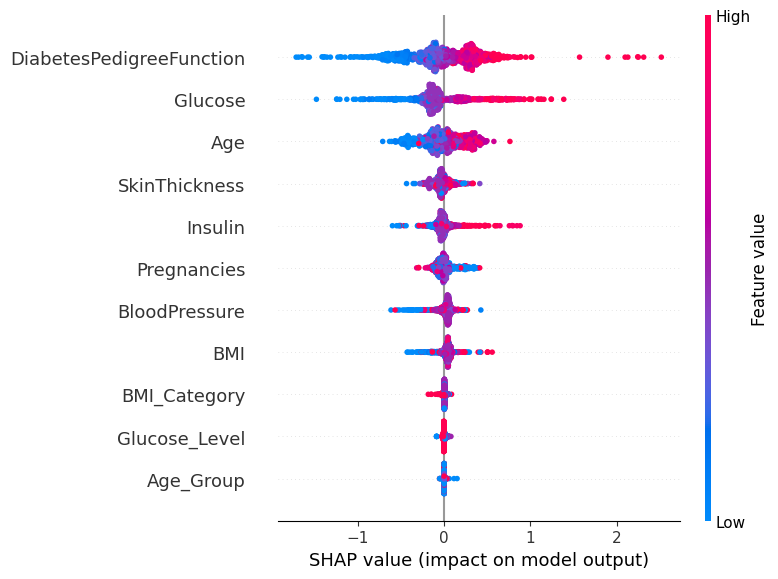

In [14]:
#SHAP
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

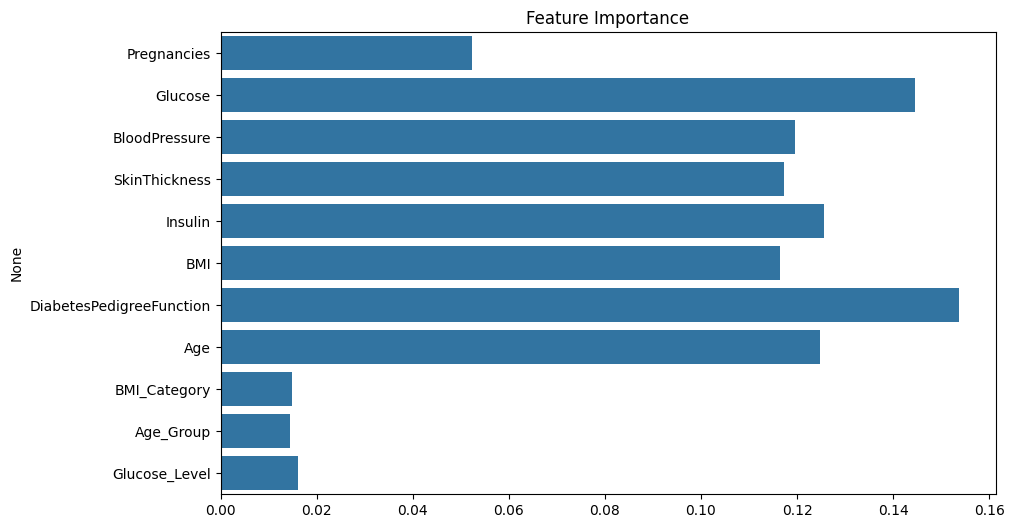

In [15]:
#Feature Importance
importance=model2.feature_importances_
features=X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importance,y=features)
plt.title("Feature Importance")
plt.show()

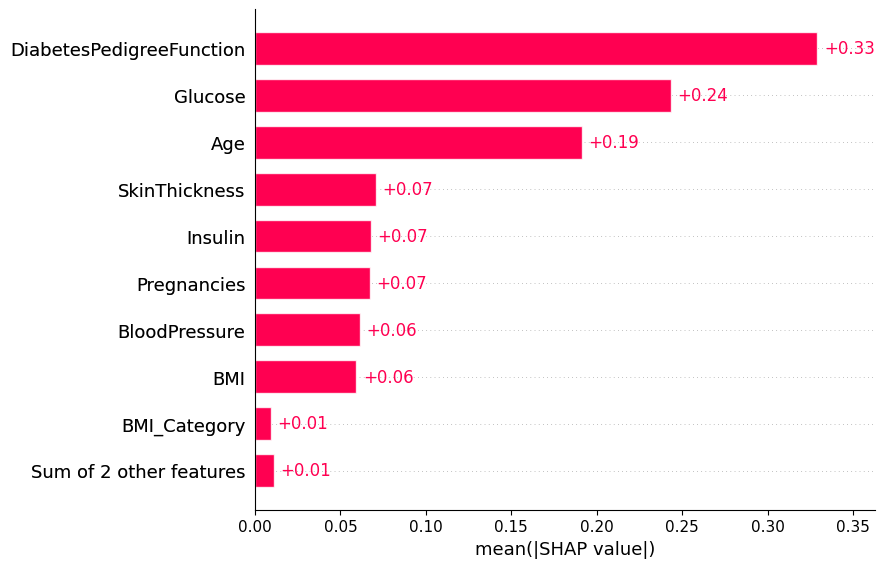

In [16]:
#SHAP Bar Plot
shap.plots.bar(shap_values)

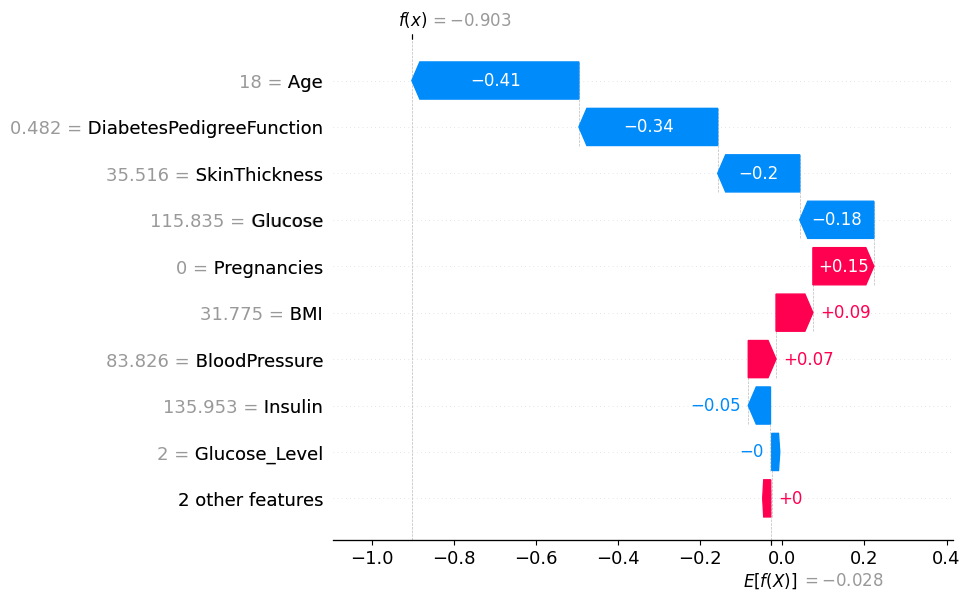

In [17]:
#SHAP Waterfall Plot
shap.plots.waterfall(shap_values[0])

In [18]:
pipeline_lr = Pipeline([
    
    ('imputer', SimpleImputer(strategy='mean')),
    
    ('scaler', StandardScaler()),
    
    ('model', LogisticRegression())
])

# Train
pipeline_lr.fit(X_train, y_train)

# Prediction
y_pred_lr = pipeline_lr.predict(X_test)

print(y_pred_lr)

[0 1 0 ... 1 0 1]


In [22]:
from sklearn.neighbors import KNeighborsClassifier
pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors=5
    ))
])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

In [24]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

In [25]:
import pickle
# Save trained model
pickle.dump(xgb_model,
            open("model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully
